# Lecture 12 

From MCMC, like we have been looking at, we only got samples from the posterior. We didn't get the evidence, which is very important in model comparison.

So let us look at some numerical techniques to calculate the evidence.

### **Savage-Dickey Density Ratio**

We want to use this when we want to compare models with nested parameters such as model 1 with has noise, and model 2 with signal and noise. The reason it is nested as Model 2 simplifies to model 1 when there is no signal.

>Another example if you would like to see the maths, is something like testing extra spatial dimensions in coulombs law, and seeing if extra spatial dimensions >introduce a small deviation:
>
>Then we can have 
>
>$$F(r) = k\frac{q_1 q_2}{r^2} \qquad \text{and} \qquad F(r) = k\frac{q_1 q_2}{r^{2+\epsilon}} $$
>
>Where epsilon represents a deviation from the inverse square law. These two models are nested as model 2 can simplify to model 1.

Anyways, back to our first example, we need to identify a parameter in the signal model that has an amplitude, $A$. When this is 0, the signal would dissapear.

Hence:

$$p_1(d|n) = p_2(d|A=0,n)$$

Using MCMC, we can map out the entire posterior distribution of model 2. For this, we need good mixing and exploration of A, so that we can reconstruct its posterior density at A=0.

The Bayes' factor can be computed using the Savage-Dickey Density Ratio:

$$\mathcal{B} = \frac{\mathcal{Z}_2}{\mathcal{Z}_1} = \frac{p(A=0)}{p(A=0|d,n)}$$

The proof for this, can be found [here](https://statproofbook.github.io/P/bf-sddr.html)



### **Product space sampling (hypermodels)**

For this model comparison, we never compute the bayesian evidence, instead we:

1. Run a large MCMC chain that includes all parameters of all models, as well as a model indexing parameter $n$
2. We define ranges for $n$ such that in different sampling ranges, it will use a specific model likelihood. For example, if $-0.5<n<0.5$, we use the likelihood for model 1.
3. After sampling sufficiently long, the MCMC chain will spend different amounts of time in different regions of $n$ in proportion to the Bayesian odds ratio.
4. Hence the ratio of samples in model sub ranges of n gives the bayesian odds ratio

### **Thermodynamic Integration**



This is used for exact calculation of Bayesian evidence. And we do the following:

1. Many MCMC chains are launched in parallel. Their likelihoods differ slightly in T ("temperature"). The temperature of a chain modifies the likelihood as:

$$p(d|\theta)_\beta = p(d|\theta)^\beta = p(d|\theta)^{1/T}$$
2. $T=1$ corresponds to the actual model likelihood
3. Raising the likelihood to the fractional power acts like taking higher roots. This flattens the likelihood surface, hence lowers high peaks and raises the deeper valleys. This allows the sampler to cross barriers and explore the entire parameter space without getting stuck near local maxima.
4. The high temp chains explore the parameter volume well, and communicate back to the $T=1$ chain to improve mixing.
5. We can use them in evidence computation:

$$\ln\mathcal{Z} = \int_0^1 \langle \ln p(d|\theta)\rangle_\beta\, d\beta$$
 
Here we have taken the mean log-likelihood of each $\beta = 1/T$ chain, then summed them over all temperatures to get the log-evidence.

### Nested Sampling

Nested sampling is different from Metropolis Hastings or Gibbs. Here,

1. One generates a set of points distributed unifromly across the entire prior volume
2. Calculate the likelihood value for each point and rank them
3. The lowest likelihood point is removed, and a new point is generated from the prior space that has a larger likelihood than the removed one
4. Repeat this. Until the cluster of points climb up the likelihood surface towards the peaks, accumulating evidence information along the way


The prior volume is defined as:

$$dX = p(\theta)d^n\theta$$

I think of dX as a small section of prior probability

And

$$X(\lambda) = \int_{p(d|\theta)>\lambda}p(\theta)d^n\theta$$

This is saying that if i draw a parameter from the prior, then the probability of it landing somewhere where $L(\theta)>\lambda$ is this.

As the likelihood increases, there is a smaller prior volume

This can transform the evidence integral into:

$$\mathcal{Z} = \int p(d|\theta)p(\theta)d^n\theta = \int_0^1 L(X)dX.$$

The algorithm starts with N points, $\theta_i, \ldots, \theta_n $ sampled from the prior:

for $i = 1 \, \text{to} \, j$ do

1. $L_i$ = min(current likelihood values of all points)
      
2. $X_i = \exp(-i/N)$ 

> This line comes from when the worst point is removed, the remaining contour will have a smaller volume: $X_i = t_i X_{i-1}$ where $t_i$ is the shrinkage factor
>
> As it is uniformly distributed so $p(t) = Nt^{N-1}$. 
>
> Also, $X_i = t_1t_2\ldots t_i$ so we change this to a log so that $E[\log(t)] = N \int^1_0 t^{N-1} \log(t) \, dt$
> $E(\log(t)) = -\frac{1}{N}$
> 
> From this, we just place it into the summation such that:
> $$\log(X_i) = \sum^i_{j=1} \log(t_j) \qquad \rightarrow \qquad X_i = e^{-i/N}$$
3. $w_i = X_{i-1} - X_i$ This is the small slice of prior volume removed during iteration $i$
4. $Z=Z+L_iw_i$ This is numerical integration, where originally we are doing $Z = \int^1_0 L(X) dX$, but we are approximating it with rectangles and effectively adding the evidence
5. Save the discarded point
6. Update the point that has the least likelihood with a MCMC step according to the prior, accepting only steps that keep the likelihood above L_i

end

return Z;

We caan also use this to find the posterior, so its overall extremely useful. There is MultiNest and pyMultiNest that do all of this.

### Dynesty

But since PyMultinest is tricky to install, there is another python implementation that can be used called Dynesty.

Let us look at some examples, first we define our likelihood to be a 3D correlated multivariate Gaussian distribution, and our prior is uniform in each dimension from $-10$ to $10$


In [1]:
import dynesty
import numpy as np

#How many dimensions does our problem have
ndim = 3

#Define the 3D correlated multivariate gaussian likelihood
C = np.identity(ndim) # Set covariance to identity matrix
C[C==0] = 0.95 # Set off diagonal terms
#print(C) # We can see that we have created an identity matrix where all the 0's have turned into 0.95

Cinv = np.linalg.inv(C) # This is the inverse or precision matrix
#print(Cinv)

lnorm = -0.5*(np.log(2*np.pi)* ndim + np.log(np.linalg.det(C))) # ln normalisation

print(lnorm)

-0.2934386945562415


The multivariate normal pdf is given as:

$$p(x) = \frac{1}{\sqrt{(2\pi)^{d} |C|}} \exp\left(-\frac{1}{2} (x-\mu)^T C^{-1} (x-\mu)\right)$$

So we can see that the log normalisation will be as what is written in the code

Furthermore, if we simplify it to what we need, we get:

$$\ln p(x) = -\frac{1}{2} x^T C^{-1} x + \text{lnorm}$$


In [2]:
def loglike(x):
    """This is the log likelihood function as we know"""

    return -0.5*np.dot(x, np.dot(Cinv,x)) + lnorm

# Now our uniform prior
def ptform(u):
    return 10.*(2.*u-1.)

The prior is 

$$\theta = 20u - 10$$

When $u = 0$, then $\theta = -10$ and when $u=1$ then $\theta = 10$

So it just maps $u \in [0,1] $ to $u \in [-10,10]$

Let us run the sampler:

In [3]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(loglike, ptform, ndim) #so clearly takes likelihood, prior then dimensions
sampler.run_nested()
sresults = sampler.results

4694it [00:01, 2709.49it/s, +500 | bound: 10 | nc: 1 | ncall: 23157 | eff(%): 22.924 | loglstar:   -inf < -0.319 <    inf | logz: -8.916 +/-  0.127 | dlogz:  0.001 >  0.509]


We have, in those simple lines of code, estimated the bayesian evidence and posterior. Let's plot this. Keep an eye on the axis, as we are moving up the likelihood contours when going from left to right on the graphs

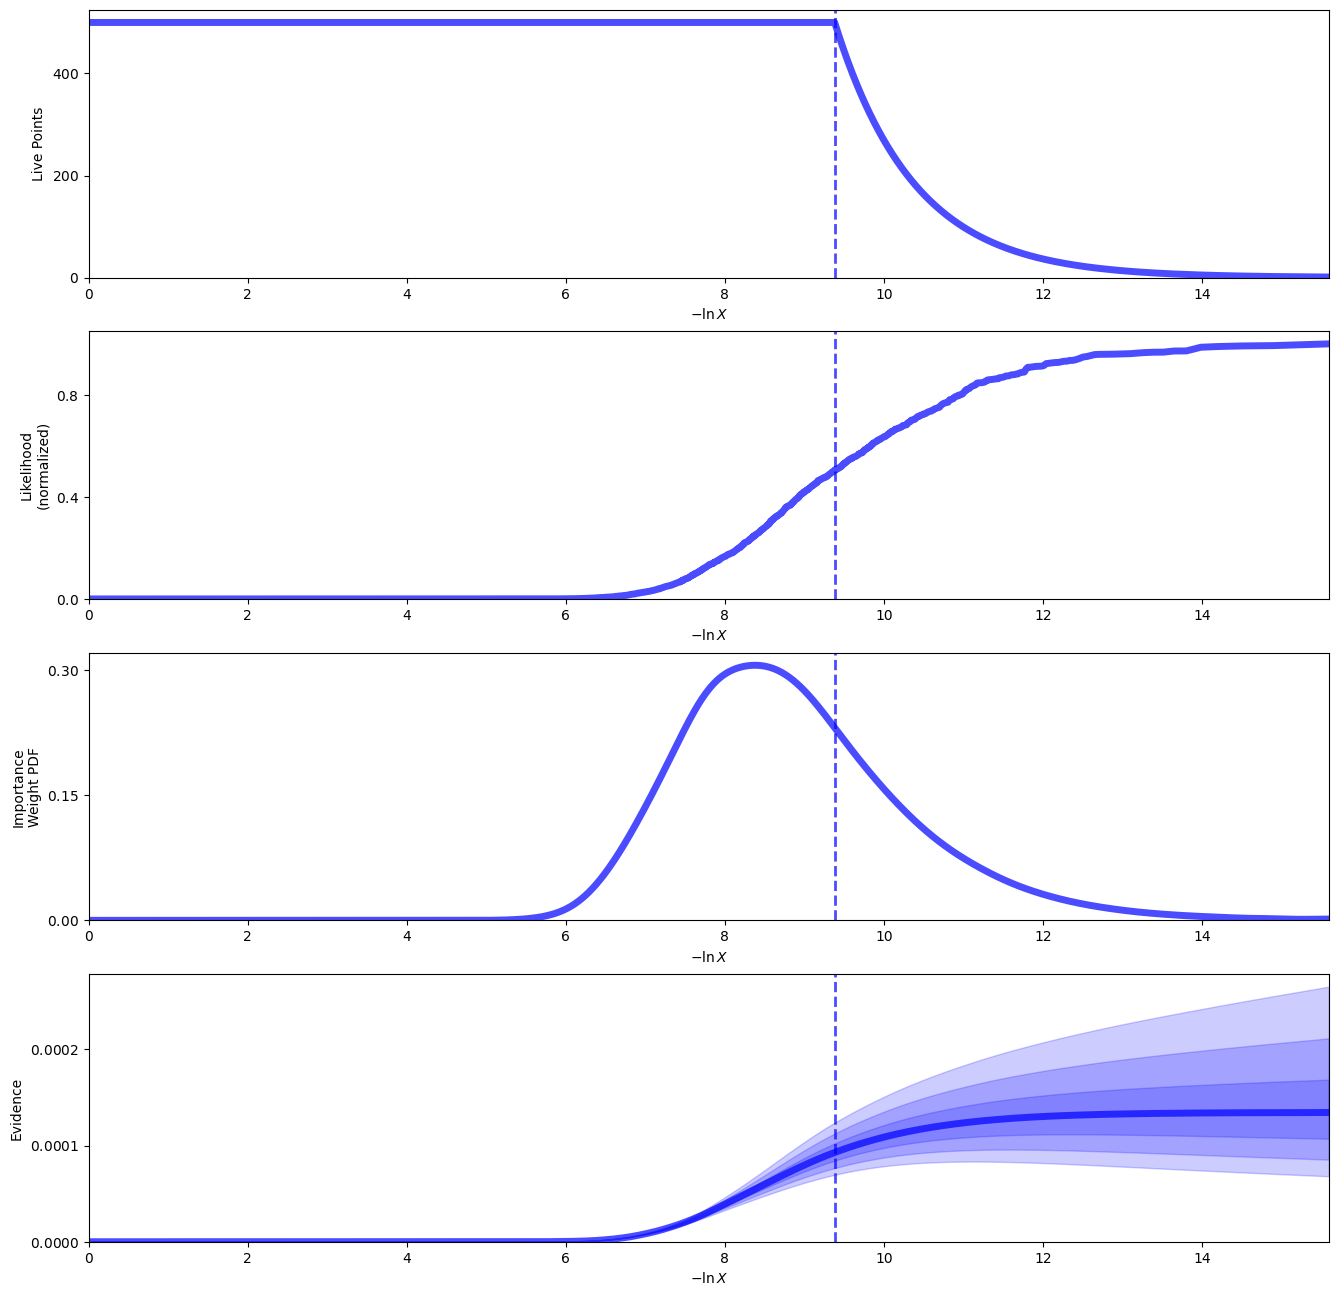

In [4]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

Now this is such a beautiful diagram, I want to take a moment and appreciate it, but this is how you interpret it

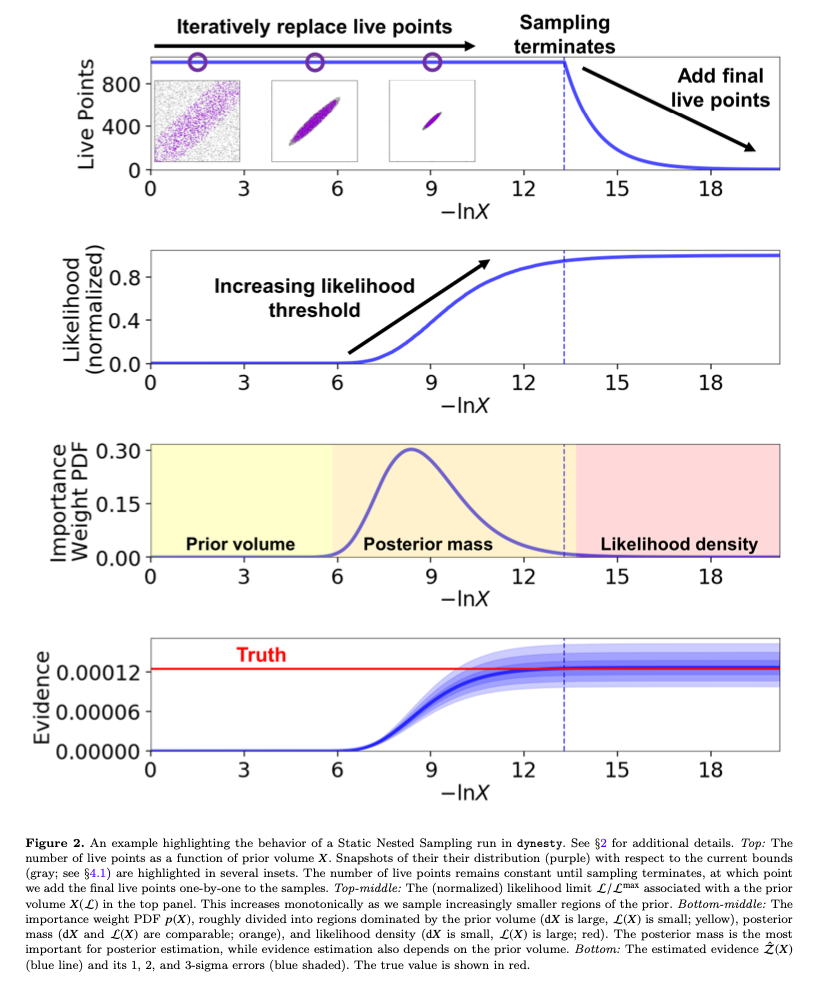

Plot parameter traces and 1D marginalized posteriors.

We will see on the left panels, that the live points started out scattereed across the prior volume, then move inwards as the sampler climbs the likelihood. Just how we described before.

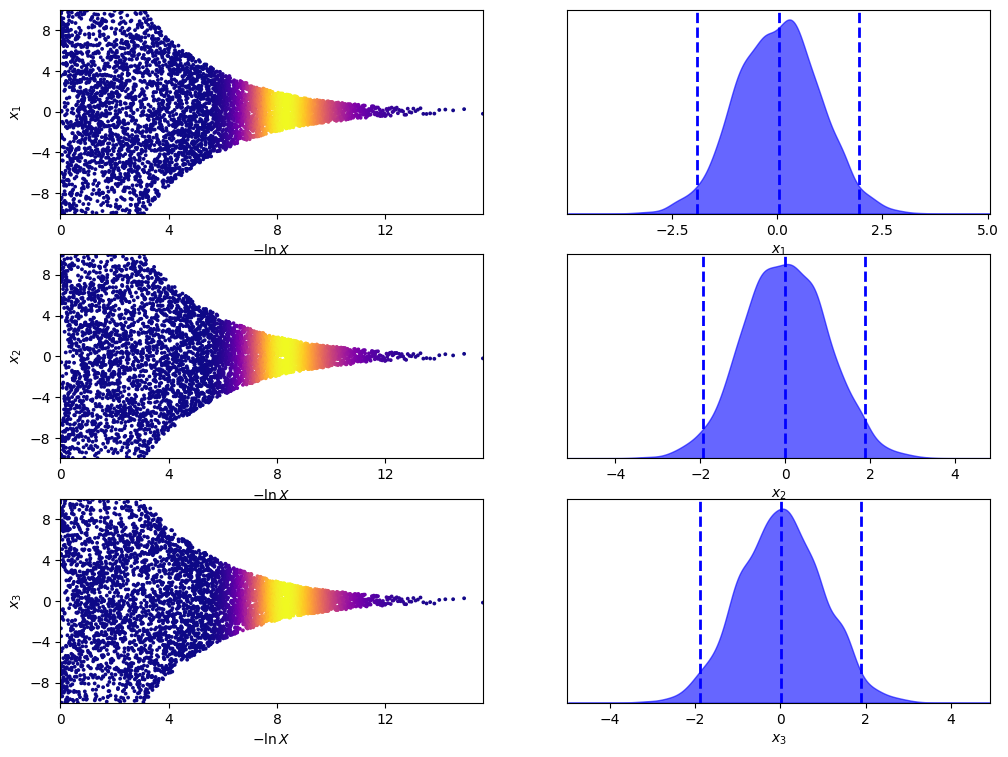

In [5]:
tfig, taxes = dyplot.traceplot(sresults)

We can use corner to plot the 2D marginalised posteriors, but lets use dynesty here to switch things ups:

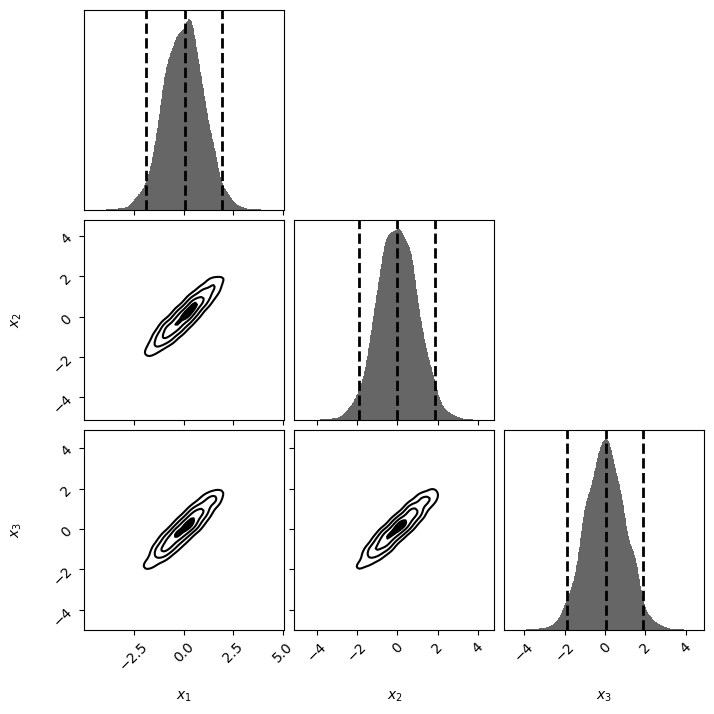

In [6]:
cfig, caxes = dyplot.cornerplot(sresults)


We can also do much more than just that:

For example we can analyse the data a lot as follows:

In [7]:
from dynesty import utils as dyfunc

samples = sresults.samples # extracting the sampling results
weights = np.exp(sresults.logwt - sresults.logz[-1]) # normalised weights

evidence = sresults.logz[-1] # evidence
print("evidence:", np.exp(evidence))

quantiles = [dyfunc.quantile(samples, [0.16, 0.84], weights = weights)
             for samples in samples.T]
print("68% parameter credible regions:\n" + str(quantiles) + "\n")

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


evidence: 0.00013428092840741645
68% parameter credible regions:
[[-0.9619533024561138, 1.0019399533809117], [-0.9759628251350397, 0.9886624459943654], [-0.9602658567856729, 0.9785328075922023]]

Mean and covariance of parameters are: [0.01753214 0.00743604 0.02012047]
[[0.95852263 0.91809159 0.90464584]
 [0.91809159 0.97380093 0.91261764]
 [0.90464584 0.91261764 0.9496478 ]]


We can also put this into corner, by postprocessing the results in dynesty to produce equal weighted samples to use in another package:

C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


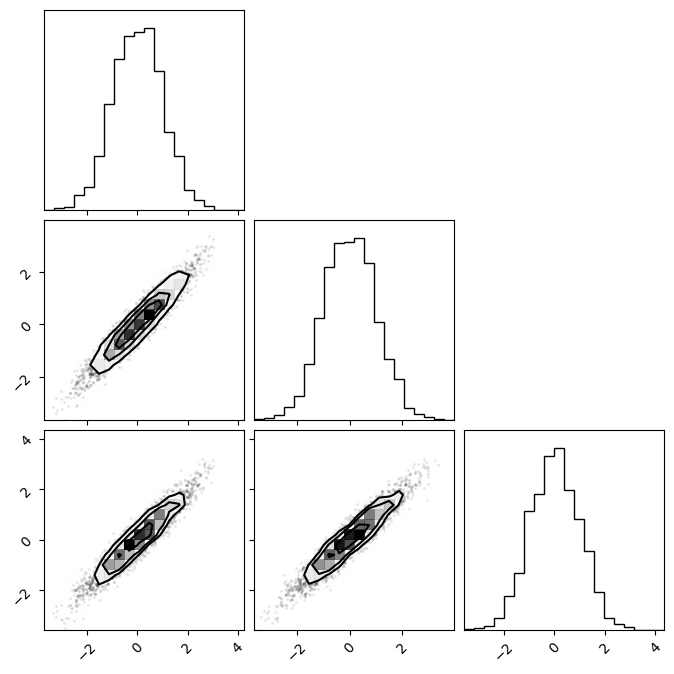

In [8]:
# Resample weighted samples.
samples_equal = dyfunc.resample_equal(samples, weights)

import corner
corner.corner(samples_equal);

In [9]:
print(sampler.citations) # This helps you with your citations

Code and Methods:
Speagle (2020): ui.adsabs.harvard.edu/abs/2020MNRAS.493.3132S
Koposov et al. (2024): doi.org/10.5281/zenodo.3348367

Nested Sampling:
Skilling (2004): ui.adsabs.harvard.edu/abs/2004AIPC..735..395S
Skilling (2006): projecteuclid.org/euclid.ba/1340370944



Bounding Method:
Feroz, Hobson & Bridges (2009): ui.adsabs.harvard.edu/abs/2009MNRAS.398.1601F

Sampling Method:




There are also some other programs that can be used such as UltraNest which is another sampler and Nessai which uses normalised flows.

## That is pretty much the day finished, I just have a lot of coding practice I wish to do now

I will first look at monte carlo integration as we had before for a crazy integral

$$\int_{0.2}^{5}\frac{e^{-x/3}\sqrt{x^3+2x+1}\,\log^2(x^2+1)\,\sin^2(3x)}{1+\tanh^2(x)}\,dx$$

Genuinely what is this thing, lets try to approximate it

In [10]:
import numpy as np

def f(x):
    return (np.exp(-x/3)*(x**3 + 2*x + 1)**(1/2) * (np.log(x**2+1))**2 * (np.sin(3*x))**2) / (1 + (np.tanh(x))**2)

min = 0.2
max = 5

randomx = np.random.uniform(min, max, 1000000)

integral = (max-min) * np.mean(f(randomx))
print(integral)

12.631418661475085


That was pretty good and quick, lets attempt to do the monty hall problem again:

In [11]:
def montyhall(where):

    labels = np.arange(3)
    doors = np.zeros(3, dtype = int)
    prize= np.random.choice(labels)
    doors[prize] = 1

    choice = np.random.choice(labels)
    notchosen = np.delete(labels,choice)

    while True:
        opened = np.random.choice(notchosen)
        if doors[opened] == 0:
            other = int(np.delete(labels, [opened,choice]))
            break

    if where == "stay":
        return doors[choice]

    elif where == "switch":
        return doors[other]

    elif where == "spectator":
        picked = np.random.choice([choice, other])
        return doors[picked]


That was okayish it took me a little while to think it through

Lectures 3 - 12 have a variety of problems with solutions, I will go through the one in L3 to start, attempt, if its wrong, look at the answer and then reattempt, then go to build up for L11 

L03:

In [12]:
import numpy as np
from matplotlib import pyplot as plt

def f(x):
    return x**3 * np.exp(-x**2/(2*sigma**2))

sigma = 8
N = 10000000
samples = np.abs(np.random.normal(0, sigma, N))


result = sigma * (np.pi / 2)**(1/2) * 1/N * np.sum(samples**3)

analytic_result = 2 * sigma**4

print("analytic result:", analytic_result)
print("our result:", result)

distance_apart = analytic_result - result 
print("distance apart:", distance_apart)


analytic result: 8192
our result: 8192.58260959807
distance apart: -0.5826095980701211


In [13]:
# Lets store these results for varied N

N = [10,100,1000,10000,100000,10000000]
results = []

for n in N:
    samples = np.abs(np.random.normal(0,sigma,n))
    result = sigma * (np.pi / 2)**(1/2) * 1/n * np.sum(samples**3)
    analytic_result = 2 * sigma**4
    distance_apart = np.abs(analytic_result - result)
    results.append(distance_apart)

print(results)

[np.float64(5069.822152741184), np.float64(377.50076290746074), np.float64(221.60496699820578), np.float64(216.2912897555252), np.float64(13.156397128235767), np.float64(3.1699569194124706)]


C:\Users\krist\AppData\Local\Temp\ipykernel_5916\772193838.py:7: RuntimeWarning: divide by zero encountered in divide
  result = sigma * (np.pi / 2)**(1/2) * 1/n * np.sum(samples**3)
C:\Users\krist\AppData\Local\Temp\ipykernel_5916\772193838.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  result = sigma * (np.pi / 2)**(1/2) * 1/n * np.sum(samples**3)


(5000.0, 12000.0)

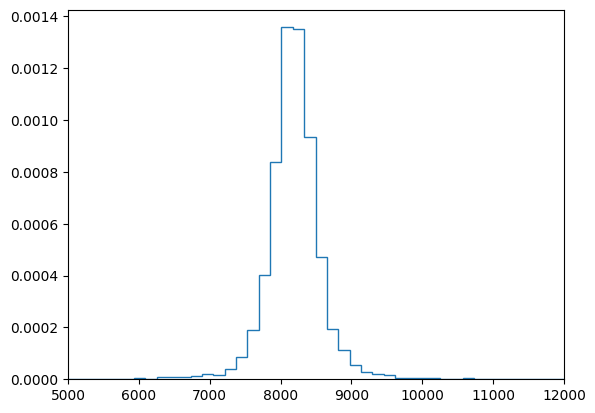

In [14]:
N = [10,100,1000,10000,100000,10000000]
N = np.arange(10000)


for n in N:
    samples = np.abs(np.random.normal(0,sigma,n))
    result = sigma * (np.pi / 2)**(1/2) * 1/n * np.sum(samples**3)
    analytic_result = 2 * sigma**4
    distance_apart = np.abs(analytic_result - result)
    results.append(result)

from matplotlib import pyplot as pyplot

plt.hist(results, bins = 100, histtype= "step", density = True)
plt.xlim(5000,12000)

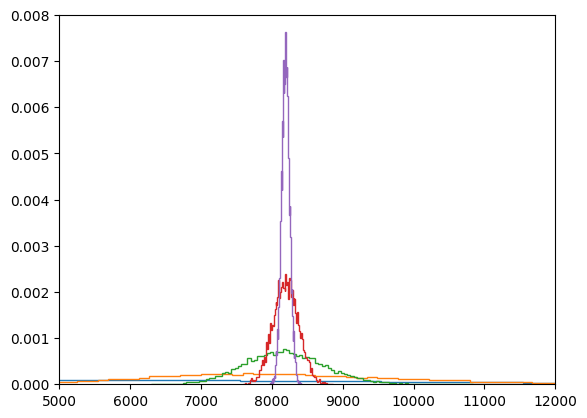

In [15]:
N = [10,100,1000,10_000,100_000]

stds = []

for n in N:
    results = []
    for i in range(10000): # should've probably done a for loop, like for i in range(10000):

        samples = np.abs(np.random.normal(0,sigma,n))
        result = sigma * (np.pi / 2)**(1/2) * 1/n * np.sum(samples**3)
        analytic_result = 2 * sigma**4
        results.append(result)
    plt.xlim(5000,12000)
    std = np.std(results)
    stds.append(std)
    plt.hist(results, bins = 100, histtype= "step", density = True)


In [16]:
stds = np.array(stds)
print(stds)

[5790.42714593 1845.40895033  575.0693526   179.63228684   57.82635607]


In [17]:
stdratio = []

for i in range(len(stds) -1):
    ratio = stds[i]/(stds[i+1])
    stdratio.append(ratio)

stdratio = np.array(stdratio)
print(stdratio)



[3.13774741 3.20901982 3.20136966 3.10640855]


gradient: -0.5012877775189752
intercept: 9.820226239951925


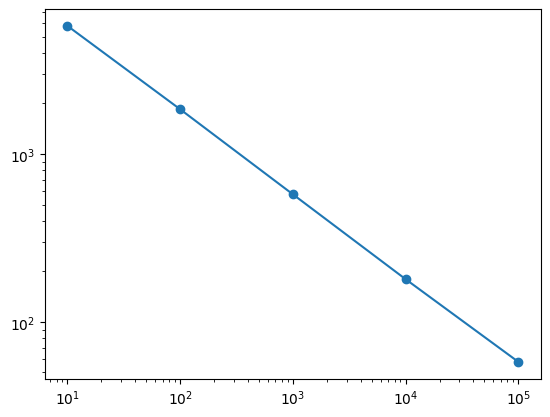

In [18]:
plt.loglog(N, stds, 'o-')
gradient, intercept = np.polyfit(np.log(N), np.log(stds), 1)

print("gradient:", gradient)
print("intercept:", intercept)

Building up to L11:

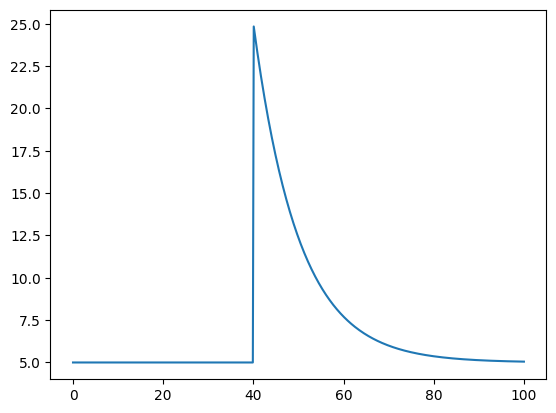

In [19]:
b = 5
A = 20
t0 = 40
alpha = 0.1

t = np.linspace(0, 100, 500)

def burst_model(t, b, A, t0, alpha):
    return np.where(
        t < t0,
        b,
        b + A* np.exp(- alpha*(t-t0))
    )

plt.plot(t, burst_model(t, b, A, t0, alpha))

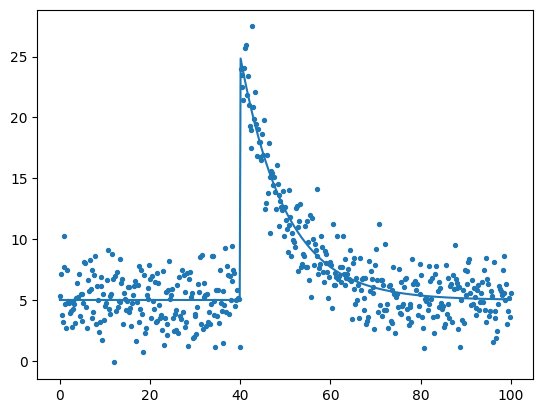

In [20]:
y_true = burst_model(t, b, A, t0, alpha)

sigma_y = 2.0

y_obs = y_true + np.random.normal(0, sigma_y, size = len(t))

plt.plot(t, y_true)
plt.scatter(t, y_obs, s = 8)

Assume independant gaussian measurements:

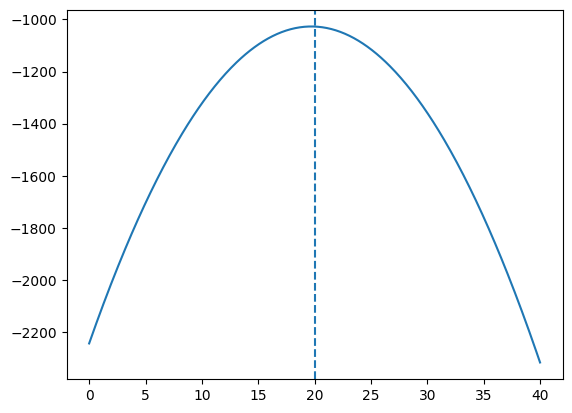

In [21]:
def loglikelihood(A_trial, t, y_obs, sigma_y):

    y_model = burst_model(t, b, A_trial, t0, alpha)
    residuals = y_obs - y_model
    return -(1/2)*np.sum((residuals)**2 / sigma_y**2 + np.log(2*np.pi*sigma_y**2))

A_grid = np.linspace(0,40,500)

loglikes = []

for A_trial in A_grid:
    k = loglikelihood(A_trial, t, y_obs, sigma_y)
    loglikes.append(k)

loglikes = np.array(loglikes)

plt.plot(A_grid,loglikes)
plt.axvline(20, linestyle = "--")

Resources:

[PROOF of Savage Dickey](https://statproofbook.github.io/P/bf-sddr.html)